# Encoding zebra finch auditory pallium responses to unoccluded song

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/le_2025_baseline.ipynb)

End-to-end demo of **`Le2025Dataset`** (Le, Bjoring & Meliza 2025,
*Nat Commun*; [DOI](https://doi.org/10.1038/s41467-025-63182-y),
[figshare](https://doi.org/10.6084/m9.figshare.29203457)) →
**StateNet GRU** → cc / cc_norm benchmark.

The Le 2025 dataset contains responses of single units in the zebra finch
auditory pallium to **8 conspecific song motifs** in up to 7 variants per
critical interval — the variants are how the paper probes the *auditory
restoration illusion*. For this baseline encoding fit, we use only the
**unoccluded `C` (Continuous) variant** of each motif: 8 stims × 10 reps
of clean natural song. That is the natural control for a stimulus-to-PSTH
encoding model — directly comparable to AA1 / NS1 / NAT4 benchmarks.

Pipeline:

1. Load the `nat8b` sub-experiment (cohort 3, 445 units, full variant set).
2. Restrict to the 8 unoccluded `C` stims with `ds.select_variant('C')`.
3. Split 6 / 1 / 1 motifs train / val / test.
4. Fit a StateNet GRU population model (one model jointly fits all 445 cells).
5. Report Pearson `cc` and noise-corrected `cc_norm` on the held-out motif.
6. (Bonus) Use the fitted model to predict responses to the occluded
   variants — a first qualitative look at whether the encoding model
   sees "restoration" in its outputs.


## Setup — Google Colab

If you're on Colab, the cell below installs deepSTRF + the `gammatone`
extra (needed to compute the paper's spectrograms). On a local install
(`pip install -e ".[le]"`) it's a no-op.

The ~3 GB Le 2025 figshare archive is auto-downloaded on first use
(`download=True` in the constructor — pulled from
[figshare](https://doi.org/10.6084/m9.figshare.29203457), unpacked
into the platformdirs cache; override via `$DEEPSTRF_DATA_DIR`).

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q 'git+https://github.com/urancon/deepSTRF.git#egg=deepSTRF[le]'
    print('deepSTRF[le] installed from GitHub.')
else:
    print('Local environment — assuming deepSTRF + gammatone are importable.')


Local environment — assuming deepSTRF + gammatone are importable.


## Imports


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio import Le2025Dataset
from deepSTRF.models.audio import StateNet
from deepSTRF.training import Fitter, set_random_seed
from deepSTRF.utils.data import neural_collate

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
set_random_seed(0)


Using device: cuda


## 1. Load Le 2025 — `nat8b` sub-experiment

`Le2025Dataset` computes the **paper-faithful gammatone**
spectrogram (50 log-spaced bands, 1–8 kHz, 2.5 ms window, 1 ms hop,
`log(P+1)` compression — Methods p. 10). We use `dt_ms=5` here for
speed; pass `dt_ms=1` for an exact paper-matched binning.

In [ ]:
ds = Le2025Dataset(
    download=True,
    experiment='nat8b',   # cohort 3, natural-syntax motifs, full variant set
    dt_ms=5.0,            # paper uses 1 ms; 5 ms keeps the demo brisk
    smooth=True,
)
print(f'Total stims:    {len(ds.stim_meta)}    (8 motifs × 12 variants)')
print(f'Total neurons:  {ds.N_neurons}')
print(f'Bands × hop:    {ds.F} × {ds.dt} ms')
print(f'Variants on disk: {sorted({m["variant"] for m in ds.stim_meta})}')
print(f'Motifs on disk:   {sorted({m["motif"] for m in ds.stim_meta})}')


## 2. Quick look — one motif, one cell

The gammatone spectrogram below is the unmodified motif (`C` variant);
the raster underneath is one cell's repeats and the trial-averaged PSTH.


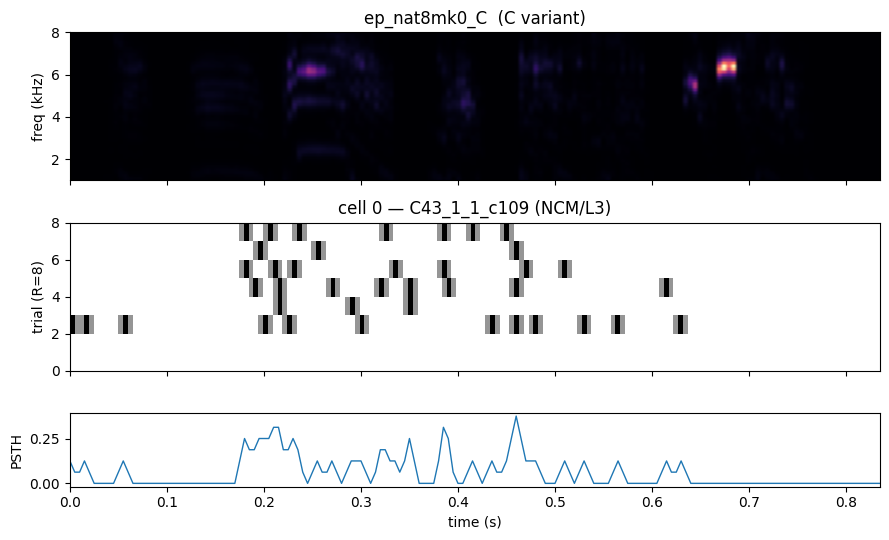

In [4]:
stim_idx = next(i for i, m in enumerate(ds.stim_meta)
                if m['motif'] == 'nat8mk0' and m['variant'] == 'C')
cell_idx = 0

spec = ds.stims[stim_idx][0].numpy()
resp = ds.responses[stim_idx][cell_idx].numpy()
psth = resp.mean(axis=0)
t = np.arange(spec.shape[1]) * ds.dt * 1e-3

fig, axs = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True,
                        gridspec_kw={'height_ratios': [2, 2, 1]})
axs[0].imshow(spec, aspect='auto', origin='lower', cmap='magma',
              extent=[t[0], t[-1], ds.fmin/1000, ds.fmax/1000])
axs[0].set_ylabel('freq (kHz)')
axs[0].set_title(f"{ds.stim_meta[stim_idx]['name']}  ({ds.stim_meta[stim_idx]['variant']} variant)")

axs[1].imshow(resp, aspect='auto', cmap='Greys',
              extent=[t[0], t[-1], 0, resp.shape[0]])
axs[1].set_ylabel(f'trial (R={resp.shape[0]})')
axs[1].set_title(f'cell {cell_idx} — {ds.nrn_meta[cell_idx]["cell_id"]} ({ds.nrn_meta[cell_idx]["area"]})')

axs[2].plot(t, psth, lw=1.0)
axs[2].set_ylabel('PSTH')
axs[2].set_xlabel('time (s)')
plt.tight_layout()
plt.show()


## 3. Restrict to unoccluded motifs and split by motif

`select_variant('C')` keeps the 8 unmodified motifs and (via the
bidirectional rule on `nrn_masks`) drops any neurons that lacked
C-variant data. We then split motif-wise: 6 train / 1 val / 1 test.

*Why split by motif rather than by trial?* Trials of the same motif are
near-identical noise realizations of the same stimulus; splitting trials
leaks the stim distribution into val/test. Motif-wise split gives a true
held-out generalization test.


In [5]:
ds.select_variant('C')
print(f'After select_variant("C"):  len(ds)={len(ds)}  N selected={len(ds._selected())}')

# 8 motifs in canonical order; reproducibility via fixed seed.
motif_order = [m['motif'] for m in ds.stim_meta if m['variant'] == 'C']
C_stim_indices = [i for i, m in enumerate(ds.stim_meta) if m['variant'] == 'C']
print('C-variant motifs:', motif_order)

train_iter = list(range(6))     # the first 6 motifs
val_iter   = [6]                # 7th motif
test_iter  = [7]                # 8th motif

train_loader = DataLoader(Subset(ds, train_iter), batch_size=1, shuffle=True,  collate_fn=neural_collate)
val_loader   = DataLoader(Subset(ds, val_iter),   batch_size=1, shuffle=False, collate_fn=neural_collate)
test_loader  = DataLoader(Subset(ds, test_iter),  batch_size=1, shuffle=False, collate_fn=neural_collate)
print(f'train: {len(train_loader.dataset)} motifs, val: {len(val_loader.dataset)}, test: {len(test_loader.dataset)}')


After select_variant("C"):  len(ds)=8  N selected=445
C-variant motifs: ['nat8mk0', 'nat8mk1', 'nat8mk2', 'nat8mk3', 'nat8mk4', 'nat8mk5', 'nat8mk6', 'nat8mk7']
train: 6 motifs, val: 1, test: 1


## 4. Standardize the spectrograms

Per-band mean/std computed on train + val and applied to all stims
(prevents test-stats leakage; see `standardize_stims` docstring).


In [6]:
ds.standardize_stims(stim_indices=[C_stim_indices[i] for i in train_iter + val_iter])
print('post-norm stim[0] min/mean/max:',
      ds.stims[C_stim_indices[0]].min().item(),
      ds.stims[C_stim_indices[0]].mean().item(),
      ds.stims[C_stim_indices[0]].max().item())


post-norm stim[0] min/mean/max: -0.8133478760719299 -0.22694870829582214 12.227806091308594


## 5. StateNet GRU population model

Per-timestep spectral encoder (`Linear` / `LocallyConnected1d`) → GRU →
per-neuron linear readout. `out_neurons=ds.N_neurons` makes one shared
backbone fit all 445 cells jointly.

The output activation defaults to `ParametricSoftplus(out_neurons)` —
per-neuron learnable sharpness + non-negative baseline; pairs naturally
with `mse_loss(pred, gt_psth)`.


In [7]:
model = StateNet(
    n_frequency_bands=ds.F,    # 50 gammatone bands
    hidden_channels=16,
    kernel_size=7, stride=3,
    connectivity='LC',
    rnn_type='GRU',
    out_neurons=ds.N_neurons,
)
print(model)
print(f'\nTrainable params: {model.count_trainable_params():,}')


StateNet(
  (wav2spec): Identity()
  (prefiltering): Identity()
  (core): Identity()
  (encoder_layers): Sequential(
    (0): LocallyConnected1d(
      (unfold): Unfold(kernel_size=(7, 1), dilation=1, padding=0, stride=3)
      (fold): Fold(output_size=(15, 1), kernel_size=(1, 1), dilation=1, padding=0, stride=1)
    )
    (1): CausalLayerNorm(
      (ln): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    )
    (2): Sigmoid()
  )
  (rnn): GRU(240, 240, batch_first=True)
  (readout): LinearReadout(
    (fc): Linear(in_features=240, out_features=445, bias=True)
    (activation): ParametricSoftplus(N=445, non_negative_output=True)
  )
)

Trainable params: 457,127


## 6. Fit

Defaults: MSE loss against the per-batch PSTH, AdamW + early stopping on
`val_cc_norm` (Schoppe-style noise-corrected correlation across cells —
see [`metrics_paradigm.md`](../docs/_source/md/metrics_paradigm.md) §6.4).

With 6 train motifs the data is tiny; this typically converges within a
minute or so on a single GPU. Don't be surprised if the held-out cc is
modest — the paper's PSTH-decoding is an easier problem than predicting
single-cell rate curves from clean spectrograms, and Le 2025's noise
ceiling on individual cells varies a lot.


In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

fitter = Fitter(
    model, train_loader, val_loader,
    optimizer=optimizer,
    device=device,
    max_epochs=120,
    patience=20,
    monitor='val_cc_norm',
    mode='max',
    log_fn=lambda d: print(
        f"epoch {d['epoch']:3d}  "
        f"train_loss={d['train_loss']:.4f}  "
        f"val_loss={d['val_loss']:.4f}  "
        f"val_cc_norm={torch.nanmean(d['val_cc_norm']):+.3f}",
        flush=True,
    ),
)
history = fitter.fit()
print(f'\nfinished after {len(history)} epochs')


epoch   0  train_loss=0.0223  val_loss=0.0137  val_cc_norm=+0.050


epoch   1  train_loss=0.0151  val_loss=0.0139  val_cc_norm=+0.052


epoch   2  train_loss=0.0148  val_loss=0.0128  val_cc_norm=+0.081


epoch   3  train_loss=0.0142  val_loss=0.0123  val_cc_norm=+0.106


epoch   4  train_loss=0.0136  val_loss=0.0122  val_cc_norm=+0.137


...

epoch  85  train_loss=0.0040  val_loss=0.0101  val_cc_norm=+0.401


epoch  86  train_loss=0.0040  val_loss=0.0104  val_cc_norm=+0.385


epoch  87  train_loss=0.0040  val_loss=0.0103  val_cc_norm=+0.393


epoch  88  train_loss=0.0039  val_loss=0.0102  val_cc_norm=+0.390



finished after 89 epochs


## 7. Training curves


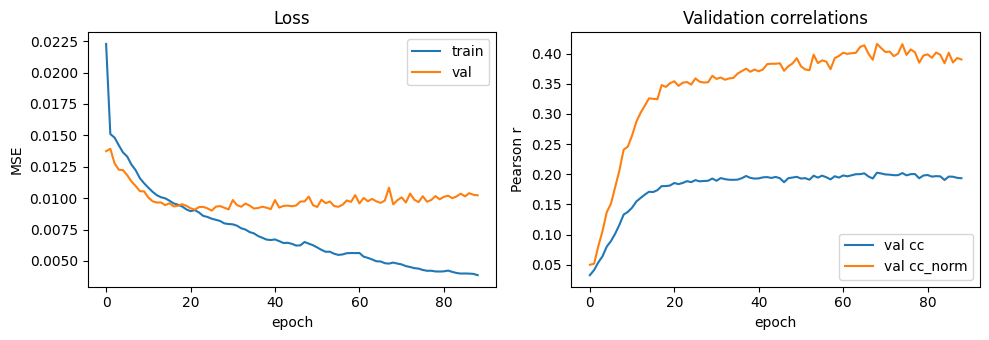

In [9]:
epochs    = [h['epoch'] for h in history]
tr_loss   = [h['train_loss'] for h in history]
v_loss    = [h['val_loss'] for h in history]
v_cc      = [torch.nanmean(h['val_cc']).item() for h in history]
v_ccnorm  = [torch.nanmean(h['val_cc_norm']).item() for h in history]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(epochs, tr_loss, label='train', lw=1.5)
axs[0].plot(epochs, v_loss,  label='val',   lw=1.5)
axs[0].set_xlabel('epoch'); axs[0].set_ylabel('MSE'); axs[0].legend(); axs[0].set_title('Loss')
axs[1].plot(epochs, v_cc,     label='val cc',      lw=1.5)
axs[1].plot(epochs, v_ccnorm, label='val cc_norm', lw=1.5)
axs[1].set_xlabel('epoch'); axs[1].set_ylabel('Pearson r'); axs[1].legend()
axs[1].set_title('Validation correlations')
plt.tight_layout(); plt.show()


## 8. Test-set evaluation

**On reading `cc_norm`.** Schoppe's noise-corrected correlation divides
the raw Pearson `cc` by the square root of the cell's signal-power
ratio (signal / total). For low-SNR cells with a single held-out motif,
the denominator can land arbitrarily close to zero — so a handful of
cells dominate the **mean**, while the **median** is robust. Report the
median; clip the histogram to keep the visualization readable.


test loss:       0.0115
test cc       mean=+0.226   median=+0.183
test cc_norm  mean=+5.683   median=+0.465


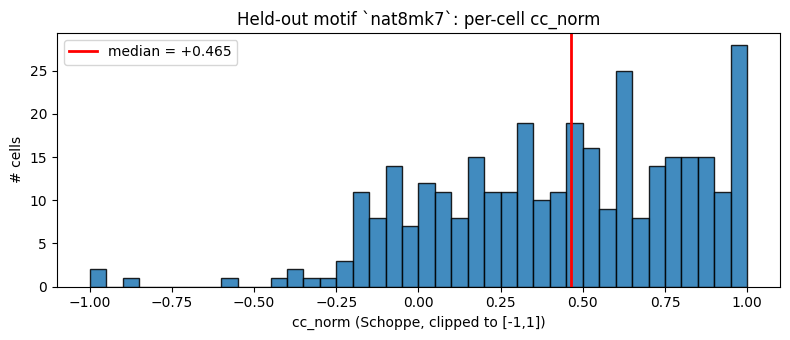

In [10]:
test_metrics = fitter.evaluate(test_loader)
test_cc      = test_metrics['cc'].cpu()
test_ccnorm  = test_metrics['cc_norm'].cpu()
print(f'test loss:       {test_metrics["loss"]:.4f}')
print(f'test cc       mean={torch.nanmean(test_cc):+.3f}   median={torch.nanmedian(test_cc):+.3f}')
print(f'test cc_norm  mean={torch.nanmean(test_ccnorm):+.3f}   median={torch.nanmedian(test_ccnorm):+.3f}')

# Clip the histogram view to [-1, 1] (a few low-SNR cells have cc_norm >> 1 due to ill-conditioned signal-power normalization).
clip = test_ccnorm.clamp(-1.0, 1.0).numpy()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(clip, bins=40, range=(-1, 1), edgecolor='black', alpha=0.85)
ax.axvline(torch.nanmedian(test_ccnorm).item(), color='red', lw=2,
           label=f'median = {torch.nanmedian(test_ccnorm):+.3f}')
ax.set_xlabel('cc_norm (Schoppe, clipped to [-1,1])'); ax.set_ylabel('# cells')
ax.set_title(f'Held-out motif `{ds.stim_meta[C_stim_indices[test_iter[0]]]["motif"]}`: per-cell cc_norm')
ax.legend(); plt.tight_layout(); plt.show()


## 9. Bonus — model predictions on occluded variants

The fitted model only ever saw clean `C` stimuli. Pushing the held-out
motif's `GB` (Gap+Burst, illusion-inducing) and `CB` (Continuous+Burst,
expected illusion) variants through it tells us how the model handles
novel acoustic statistics outside its training distribution. *This is
not the paper's restoration analysis* (which works in PLS latent space
across the whole population), but it's a cheap qualitative sanity check.


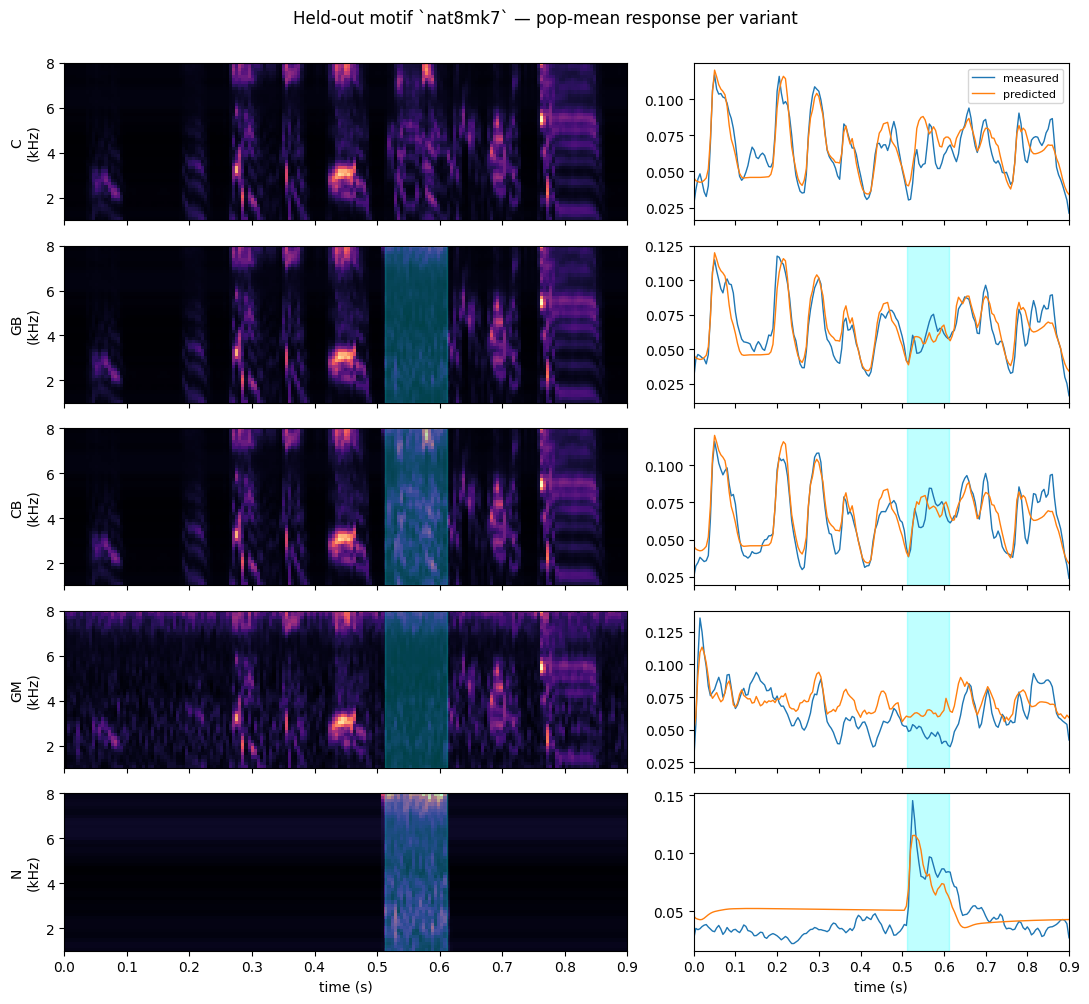

In [11]:
ds.reset_stim_selection()
held_out_motif = ds.stim_meta[C_stim_indices[test_iter[0]]]['motif']
show_variants = ['C', 'GB', 'CB', 'GM', 'N']
show_ci = 1

fig, axs = plt.subplots(len(show_variants), 2, figsize=(11, 2.0*len(show_variants)),
                        sharex=True, gridspec_kw={'width_ratios': [3, 2]})
model.eval()
model.to(device)
with torch.no_grad():
    for row, variant in enumerate(show_variants):
        candidates = [i for i, m in enumerate(ds.stim_meta)
                      if m['motif'] == held_out_motif and m['variant'] == variant
                      and (m['critical_interval'] in (None, show_ci))]
        if not candidates:
            for ax in axs[row]:
                ax.set_visible(False)
            continue
        s_idx = candidates[0]
        meta = ds.stim_meta[s_idx]
        spec = ds.stims[s_idx]
        t = np.arange(spec.shape[-1]) * ds.dt * 1e-3
        # batch axis
        x = spec.unsqueeze(0).to(device)
        pred = model(x).cpu().squeeze(0).squeeze(1)  # (N, T)
        # ground truth on selected neurons
        resp = ds.responses[s_idx]
        psth = torch.stack([r.float().mean(0) if r.numel() > 1 else torch.full((spec.shape[-1],), float('nan'))
                            for r in resp])  # (N, T)
        # plot stim spectrogram
        axs[row, 0].imshow(spec[0].numpy(), aspect='auto', origin='lower', cmap='magma',
                           extent=[t[0], t[-1], ds.fmin/1000, ds.fmax/1000])
        if not np.isnan(meta['ci_onset_s']):
            axs[row, 0].axvspan(meta['ci_onset_s'], meta['ci_offset_s'], color='cyan', alpha=0.25)
        axs[row, 0].set_ylabel(f"{variant}\n(kHz)")
        # plot pop-mean predicted vs measured PSTH
        axs[row, 1].plot(t, psth.nanmean(0).numpy(), label='measured', lw=1.0)
        axs[row, 1].plot(t, pred.mean(0).numpy(),    label='predicted', lw=1.0)
        if not np.isnan(meta['ci_onset_s']):
            axs[row, 1].axvspan(meta['ci_onset_s'], meta['ci_offset_s'], color='cyan', alpha=0.25)
        if row == 0:
            axs[row, 1].legend(fontsize=8, loc='upper right')
axs[-1, 0].set_xlabel('time (s)'); axs[-1, 1].set_xlabel('time (s)')
fig.suptitle(f'Held-out motif `{held_out_motif}` — pop-mean response per variant', y=1.0)
plt.tight_layout(); plt.show()


### Where to go next

- **Leave-one-motif-out cross-validation** — average cc / cc_norm across
  all 8 held-out motifs for a low-variance benchmark number.
- **All variants in training** — fit the encoding model on `C + G + N +
  CB + CM` (the variants that contain no "information beyond the noise")
  to give it more data and a wider acoustic distribution.
- **Restoration metric** — replicate the paper's PLS / restoration-index
  pipeline in deepSTRF, contrasting GB vs CB trajectories in the model's
  hidden state (rather than the recorded population). See `select_restoration_quartet`.
- **synth8b** — re-fit on the scrambled-syntax cohort; does cc_norm
  drop, as the paper's restoration-index does?
